In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()

Saving student_data.csv to student_data.csv


In [4]:
df = pd.read_csv("student_data.csv")

In [5]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [6]:
df.shape

(395, 33)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [8]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df[['sex',
         'age',
         'studytime',
         'failures',
         'internet',
         'absences',
         'G1',
         'G2',
         'G3']]

In [11]:
df.columns = [
    'Gender',
    'Age',
    'Study_Time',
    'Failures',
    'Internet',
    'Absences',
    'Test1_Marks',
    'Test2_Marks',
    'Final_Marks'
]

In [12]:
df.insert(0, 'Student_ID', range(1, len(df)+1))

In [13]:
df = df.copy()

In [14]:
df.head()

,Student_ID,Gender,Age,Study_Time,Failures,Internet,Absences,Test1_Marks,Test2_Marks,Final_Marks
0,1,F,18,2,0,no,6,5,6,6
1,2,F,17,2,0,yes,4,5,5,6
2,3,F,15,2,3,yes,10,7,8,10
3,4,F,15,3,0,yes,2,15,14,15
4,5,F,16,2,0,no,4,6,10,10


In [15]:
df["Average"] = (
    df["Test1_Marks"] +
    df["Test2_Marks"] +
    df["Final_Marks"]
) / 3

In [16]:
def grade(avg):
    if avg >= 16:
        return "A"
    elif avg >= 14:
        return "B"
    elif avg >= 12:
        return "C"
    elif avg >= 10:
        return "D"
    else:
        return "F"

df["Grade"] = df["Average"].apply(grade)

In [17]:
df["Result"] = df["Average"].apply(
    lambda x: "Pass" if x >= 10 else "Fail"
)

In [18]:
df.head()

,Student_ID,Gender,Age,Study_Time,Failures,Internet,Absences,Test1_Marks,Test2_Marks,Final_Marks,Average,Grade,Result
0,1,F,18,2,0,no,6,5,6,6,5.666667,F,Fail
1,2,F,17,2,0,yes,4,5,5,6,5.333333,F,Fail
2,3,F,15,2,3,yes,10,7,8,10,8.333333,F,Fail
3,4,F,15,3,0,yes,2,15,14,15,14.666667,B,Pass
4,5,F,16,2,0,no,4,6,10,10,8.666667,F,Fail


In [19]:
top_students = df.sort_values(
    by="Average",
    ascending=False
).head(10)

top_students

,Student_ID,Gender,Age,Study_Time,Failures,Internet,Absences,Test1_Marks,Test2_Marks,Final_Marks,Average,Grade,Result
47,48,M,16,4,0,yes,4,19,19,20,19.333333,A,Pass
374,375,F,18,3,0,yes,0,19,18,19,18.666667,A,Pass
110,111,M,15,1,0,yes,6,18,19,19,18.666667,A,Pass
113,114,M,15,1,0,yes,10,18,19,19,18.666667,A,Pass
42,43,M,15,2,0,yes,2,19,18,18,18.333333,A,Pass
286,287,F,18,3,0,yes,5,18,18,19,18.333333,A,Pass
245,246,M,16,1,0,yes,6,18,18,18,18.000000,A,Pass
293,294,F,17,4,0,no,6,18,18,18,18.000000,A,Pass
129,130,M,16,1,0,yes,8,18,18,18,18.000000,A,Pass
198,199,F,17,1,1,yes,24,18,18,18,18.000000,A,Pass


In [20]:
df.head()

,Student_ID,Gender,Age,Study_Time,Failures,Internet,Absences,Test1_Marks,Test2_Marks,Final_Marks,Average,Grade,Result
0,1,F,18,2,0,no,6,5,6,6,5.666667,F,Fail
1,2,F,17,2,0,yes,4,5,5,6,5.333333,F,Fail
2,3,F,15,2,3,yes,10,7,8,10,8.333333,F,Fail
3,4,F,15,3,0,yes,2,15,14,15,14.666667,B,Pass
4,5,F,16,2,0,no,4,6,10,10,8.666667,F,Fail


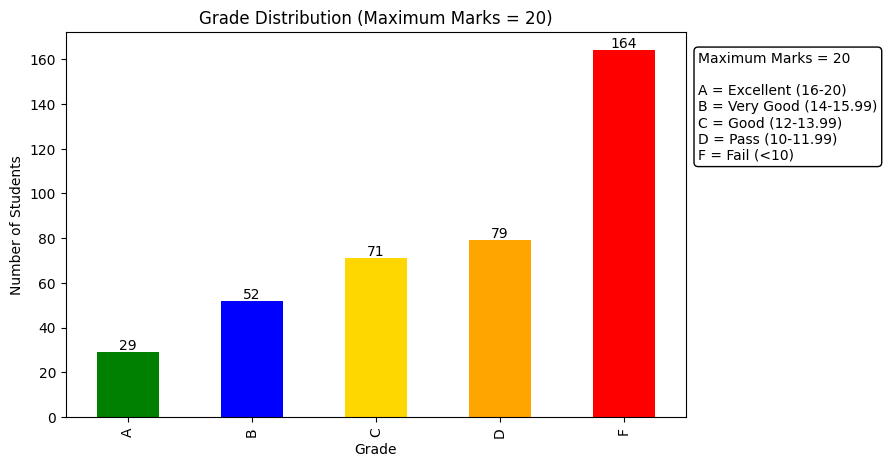

In [21]:
import matplotlib.pyplot as plt

grade_counts = df["Grade"].value_counts().sort_index()

colors = ['green', 'blue', 'gold', 'orange', 'red']

ax = grade_counts.plot(
    kind='bar',
    color=colors,
    figsize=(8,5)
)

plt.title("Grade Distribution (Maximum Marks = 20)")
plt.xlabel("Grade")
plt.ylabel("Number of Students")

# Bar mela values display panna
for i, v in enumerate(grade_counts):
    ax.text(i, v + 1, str(v), ha='center')

# Grade explanation box
plt.text(
    1.02, 0.95,
    "Maximum Marks = 20\n\n"
    "A = Excellent (16-20)\n"
    "B = Very Good (14-15.99)\n"
    "C = Good (12-13.99)\n"
    "D = Pass (10-11.99)\n"
    "F = Fail (<10)",
    transform=ax.transAxes,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        edgecolor='black'
    )
)

plt.show()

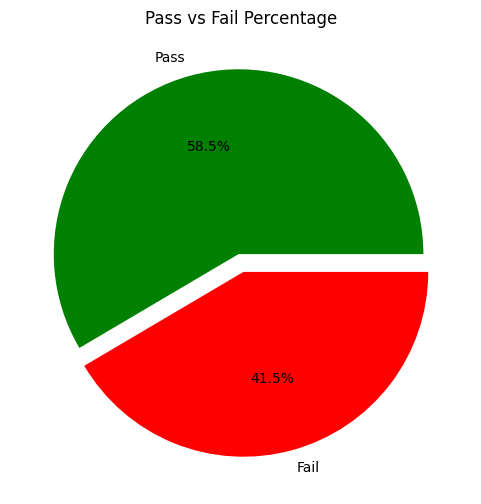

In [22]:
result_counts = df["Result"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    result_counts,
    labels=result_counts.index,
    autopct='%1.1f%%',
    colors=['green', 'red'],
    explode=(0.05, 0.05)
)

plt.title("Pass vs Fail Percentage")
plt.show()

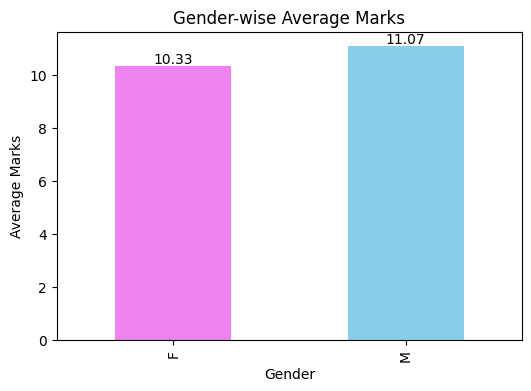

In [23]:
gender_avg = df.groupby("Gender")["Average"].mean()

ax = gender_avg.plot(
    kind='bar',
    color=['violet', 'skyblue'],
    figsize=(6,4)
)

plt.title("Gender-wise Average Marks")
plt.xlabel("Gender")
plt.ylabel("Average Marks")

for i, v in enumerate(gender_avg):
    ax.text(i, v + 0.1, round(v,2), ha='center')

plt.show()

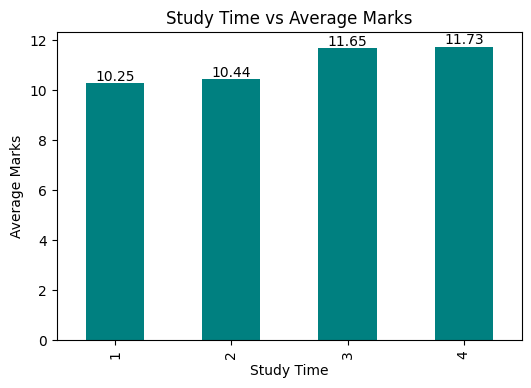

In [24]:
study_avg = df.groupby("Study_Time")["Average"].mean()

ax = study_avg.plot(
    kind='bar',
    color='teal',
    figsize=(6,4)
)

plt.title("Study Time vs Average Marks")
plt.xlabel("Study Time")
plt.ylabel("Average Marks")

for i, v in enumerate(study_avg):
    ax.text(i, v + 0.1, round(v,2), ha='center')

plt.show()